# Setup and Data Loading
This cell imports the libraries required for data analysis and enables plots to appear directly in the notebook.

In [78]:
# ==========================================================
# STEP 1: Import Required Libraries
# ==========================================================

# Import pandas for data manipulation
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import seaborn for attractive plots
import seaborn as sns

# Display plots inside Jupyter Notebook
%matplotlib inline

# Loading the Dataset
This cell loads the online retail data from a CSV file into a pandas DataFrame for analysis.

In [79]:
# ==========================================================
# STEP 2: Load Dataset
# ==========================================================

# Load dataset
df = pd.read_csv("C:\\Users\\Muneeza Shehwar\\Downloads\\data.csv\\data.csv", encoding="latin1")

# Previewing the Data
This cell shows the first few rows of the dataset so the structure and contents can be reviewed quickly.

In [80]:
# Display first five rows

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Exploring Dataset Structure
This cell prints the dataset dimensions, column names, and basic information about each column.

In [81]:
# ==========================================================
# STEP 3: Inspect Dataset
# ==========================================================

# Display shape
print("Dataset Shape:")
print(df.shape)

print("\n")

# Display information
print(df.info())

print("\n")

# Display column names
print(df.columns)

Dataset Shape:
(541909, 8)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


# Reviewing Summary Statistics
This cell summarizes the numeric columns to highlight ranges, averages, and spread in the data.

In [82]:
# Summary statistics of numerical columns

df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# Checking Missing Values
This cell counts missing values in each column so data quality issues can be identified.

In [83]:
# ==========================================================
# STEP 4: Check Missing Values
# ==========================================================

# Count missing values in each column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# Cleaning Text Fields
This cell fills missing product descriptions with a placeholder value to keep the dataset consistent.

In [84]:
#handle missing values
# Fill missing Description with "Unknown"
df["Description"] = df["Description"].fillna("Unknown")

# Removing Incomplete Records
This cell removes rows that do not have a customer ID, since these entries are not useful for customer-based analysis.

In [85]:
# Remove rows where CustomerID is missing
df = df.dropna(subset=["CustomerID"])

# Rechecking Missing Data
This cell verifies that the earlier cleaning steps removed the missing values successfully.

In [86]:
# Check missing values again
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

# Checking for Duplicates
This cell checks whether duplicate rows are present in the dataset before the data is treated further.

In [87]:
# ==========================================================
# STEP 6: Check Duplicate Records
# ==========================================================

# Count duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 5225


# Removing Duplicate Rows
This cell removes duplicate records so the analysis is based on unique transactions.

In [88]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Duplicates removed successfully.")

Duplicates removed successfully.


# Confirming Cleanup
This cell confirms that duplicate rows were successfully removed from the dataset.

In [89]:
# Check duplicates again
print(df.duplicated().sum())

0


# Reviewing Data Types
This cell shows the current data types of each column before any conversion is applied.

In [90]:
# STEP 7: Check Data Types
# ==========================================================

# Display data types
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

# Converting Data Types
This cell converts the invoice date and customer ID columns into more suitable formats for analysis.

In [91]:
# ==========================================================
# STEP 8: Convert Data Types
# ==========================================================

# Convert InvoiceDate to datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Convert CustomerID to integer
df["CustomerID"] = df["CustomerID"].astype(int)

# Verifying Converted Fields
This cell checks the updated data types after the conversion step to ensure the transformation worked correctly.

In [92]:
# Verify updated data types
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

# Final Data Review
This cell performs a final inspection of the cleaned dataset before exporting it.

In [93]:
# ==========================================================
# STEP 9: Final Inspection
# ==========================================================

print("Shape of Clean Dataset:")
print(df.shape)

print("\n")

print(df.info())

print("\n")

# Display first five rows
df.head()

Shape of Clean Dataset:
(401604, 8)


<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  int64         
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.6+ MB
None




,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


# Saving the Clean Dataset
This cell exports the cleaned data to a new CSV file so it can be reused later.

In [94]:
# ==========================================================
# STEP 10: Save Clean Dataset
# ==========================================================

# Save cleaned dataset into a new CSV file
df.to_csv("cleaned_online_retail.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Visualizing Country Orders
This cell creates a bar chart showing the countries with the highest number of orders.

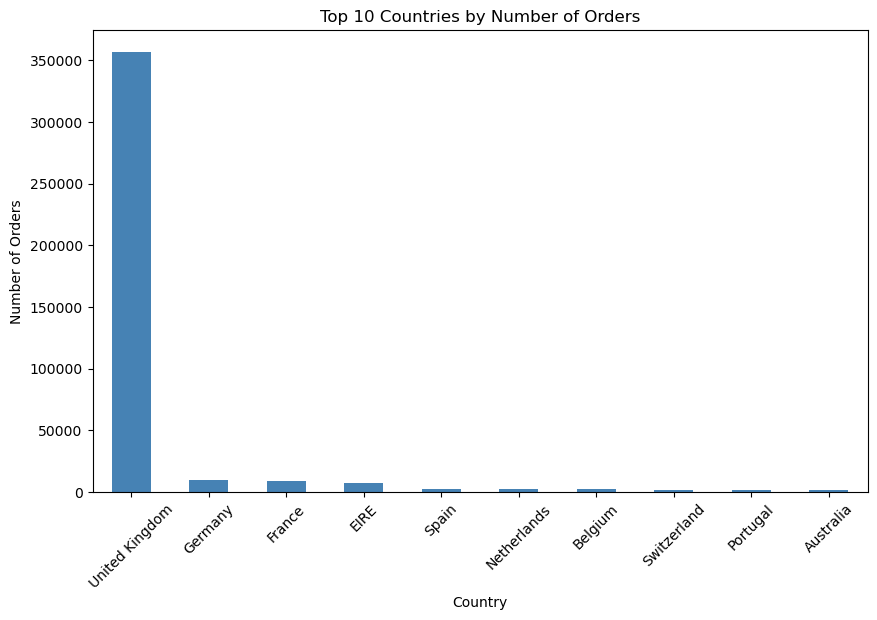

In [95]:
# ==========================================================
# GRAPH 1: Top 10 Countries by Number of Orders
# ==========================================================

# Count orders by country
country_orders = df["Country"].value_counts().head(10)

# Create figure
plt.figure(figsize=(10,6))

# Plot bar chart
country_orders.plot(kind="bar", color="steelblue")

# Add title and labels
plt.title("Top 10 Countries by Number of Orders")
plt.xlabel("Country")
plt.ylabel("Number of Orders")

# Rotate x-axis labels
plt.xticks(rotation=45)

# Show graph
plt.show()

# Plotting Monthly Sales
This cell summarizes sales by month and visualizes the trend over time.

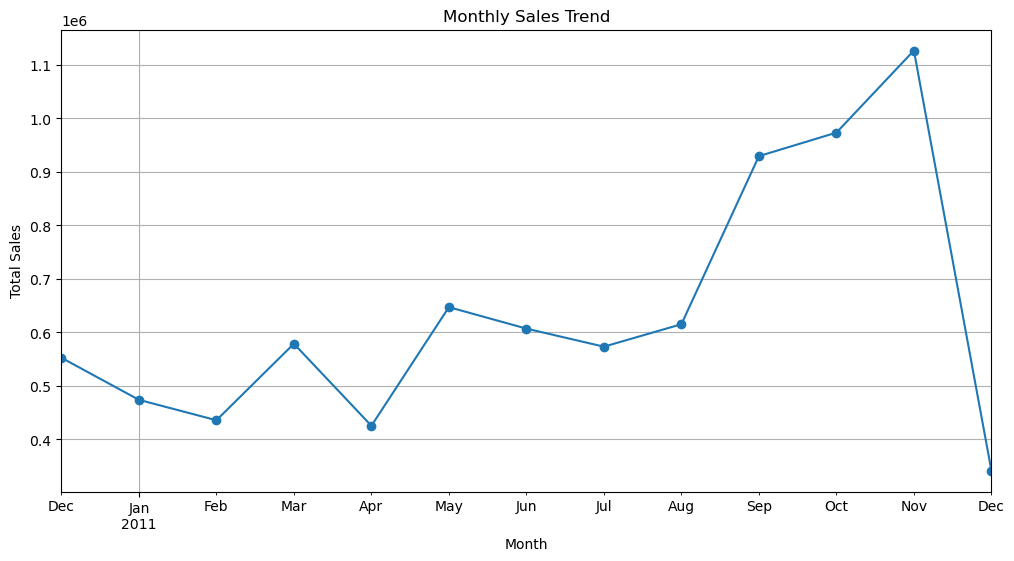

In [96]:
# ==========================================================
# GRAPH 2: Monthly Sales Trend
# ==========================================================

# Create TotalPrice column
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Extract month
df["Month"] = df["InvoiceDate"].dt.to_period("M")

# Calculate monthly sales
monthly_sales = df.groupby("Month")["TotalPrice"].sum()

# Create figure
plt.figure(figsize=(12,6))

# Plot line chart
monthly_sales.plot(marker="o")

# Title and labels
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

# Grid
plt.grid(True)

plt.show()

# Creating a Country Share Pie Chart
This cell builds a pie chart to show the share of orders contributed by the top five countries.

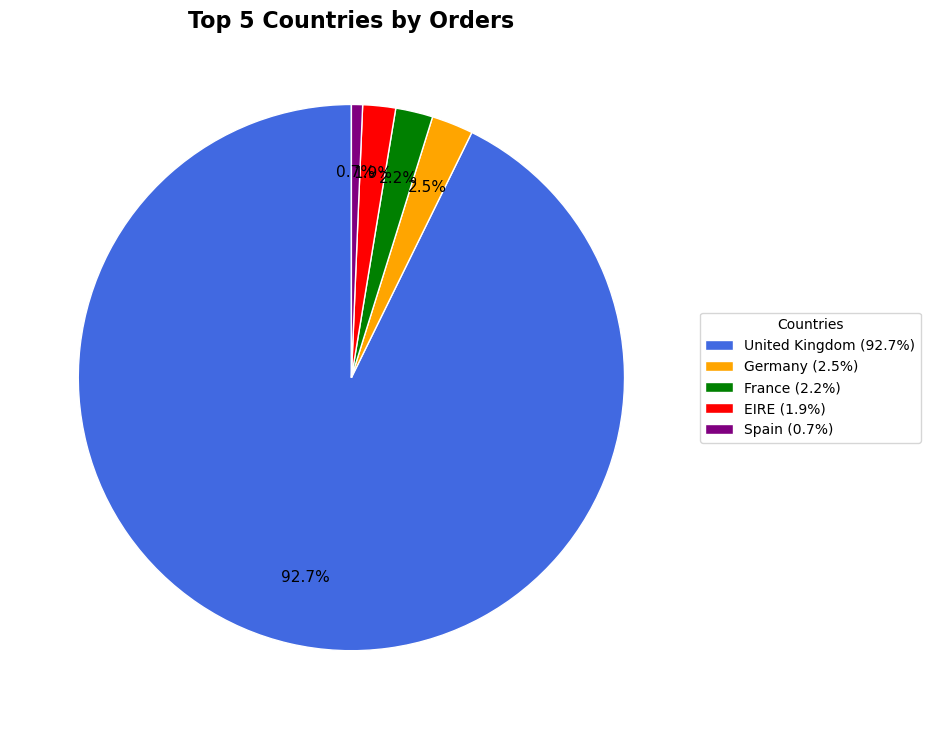

In [97]:
# ==========================================================
# GRAPH 3: Professional Pie Chart
# ==========================================================

import matplotlib.pyplot as plt

# Top 5 countries
top5 = df["Country"].value_counts().head(5)

# Colors
colors = ["royalblue", "orange", "green", "red", "purple"]

# Figure
plt.figure(figsize=(9,8))

# Pie Chart
wedges, texts, autotexts = plt.pie(
    top5,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,       # Percentage inside slices
    textprops={"fontsize":11},
    wedgeprops={"edgecolor":"white"}
)

# Title
plt.title("Top 5 Countries by Orders", fontsize=16, fontweight="bold")

# Legend (Country + Percentage)
labels = [
    f"{country} ({value/top5.sum()*100:.1f}%)"
    for country, value in zip(top5.index, top5.values)
]

plt.legend(
    wedges,
    labels,
    title="Countries",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

# Highlighting Best-Selling Products
This cell identifies the top-selling products and visualizes their total quantities sold.

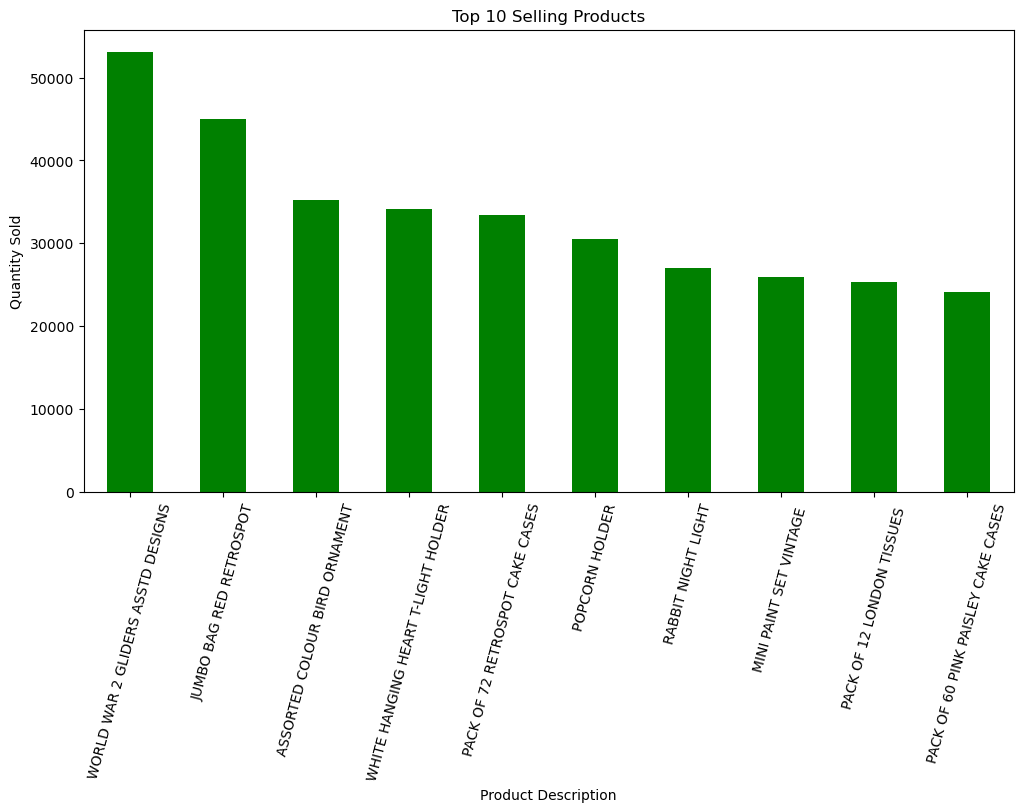

In [98]:
# ==========================================================
# GRAPH 5: Top 10 Selling Products
# ==========================================================

# Top selling products
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar", color="green")

plt.title("Top 10 Selling Products")

plt.xlabel("Product Description")

plt.ylabel("Quantity Sold")

plt.xticks(rotation=75)

plt.show()

# Finding the Highest Unit Price
This cell calculates the maximum unit price present in the dataset and displays it.

In [99]:
# Maximum Unit Price
max_price = df["UnitPrice"].max()

print("Maximum Unit Price:", max_price)

Maximum Unit Price: 38970.0


# Inspecting Price Distribution
This cell plots a histogram of unit prices to show how prices are distributed across the dataset.

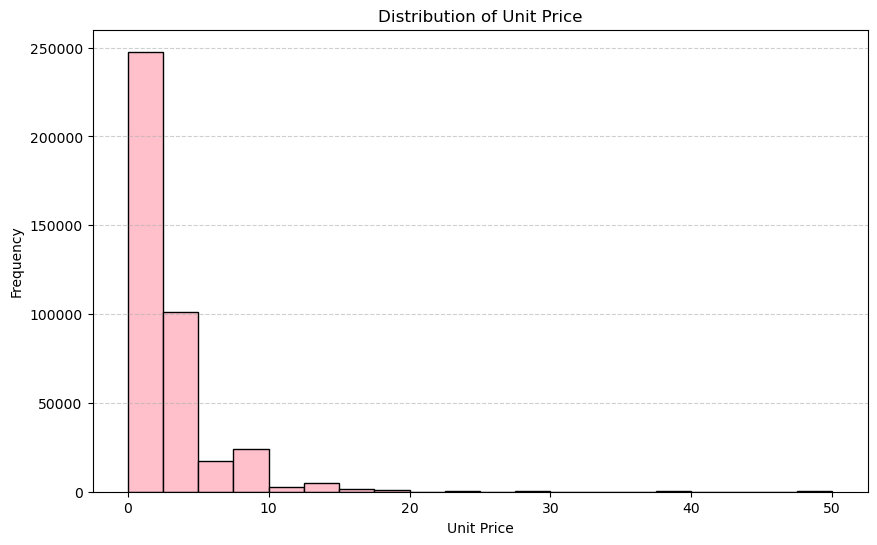

In [100]:
# ==========================================================
# GRAPH 4: Distribution of Unit Price (Histogram)
# ==========================================================

# Keep only valid prices (99% of the data)
hist_df = df[(df["UnitPrice"] > 0) & (df["UnitPrice"] <= 50)]

# Create figure
plt.figure(figsize=(10,6))

# Plot histogram
plt.hist(
    hist_df["UnitPrice"],
    bins=20,
    color="pink",
    edgecolor="black"
)

# Add title and labels
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

# Add grid
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Show graph
plt.show()